In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

filename = '../data/sales_predictors.csv'
df = pd.read_csv(filename)

x = df[['TV']].values
y = df[['Sales']].values

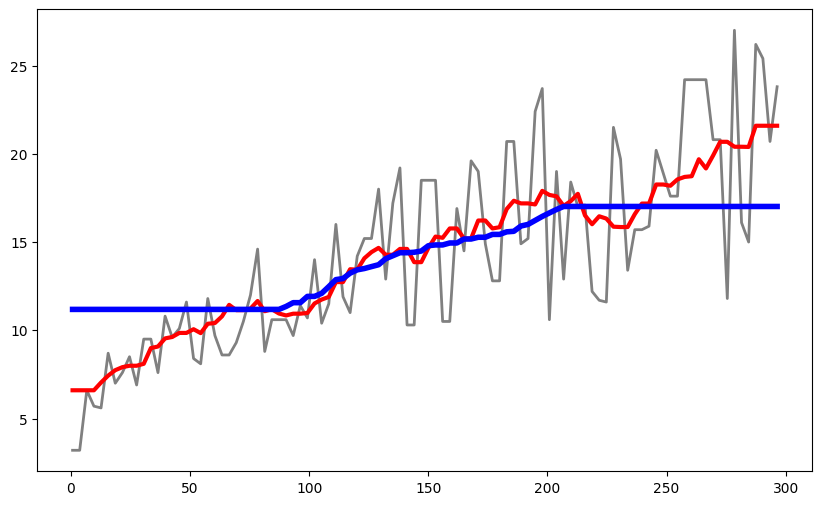

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        train_size=0.6,
        random_state=66
        )

k_value_min = 1
k_value_max = 70
k_list = np.linspace(k_value_min, k_value_max, num=70, dtype=int)

fig, ax = plt.subplots(figsize=(10,6))
knn_dict = {}
j = 0

for k_value in k_list:
    model = KNeighborsRegressor(n_neighbors=int(k_value))
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    MSE = mean_squared_error(y_test, y_pred)
    knn_dict[k_value] = MSE
    
    colors = ['grey','r','b']
    if k_value in [1,10,70]:
        xvals = np.linspace(x.min(),x.max(),100).reshape(-1, 1)
        ypreds = model.predict(xvals)
        ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
        j+=1

The best k value is  [np.int64(9)] with a MSE of  13.046766975308643


<Figure size 640x480 with 0 Axes>

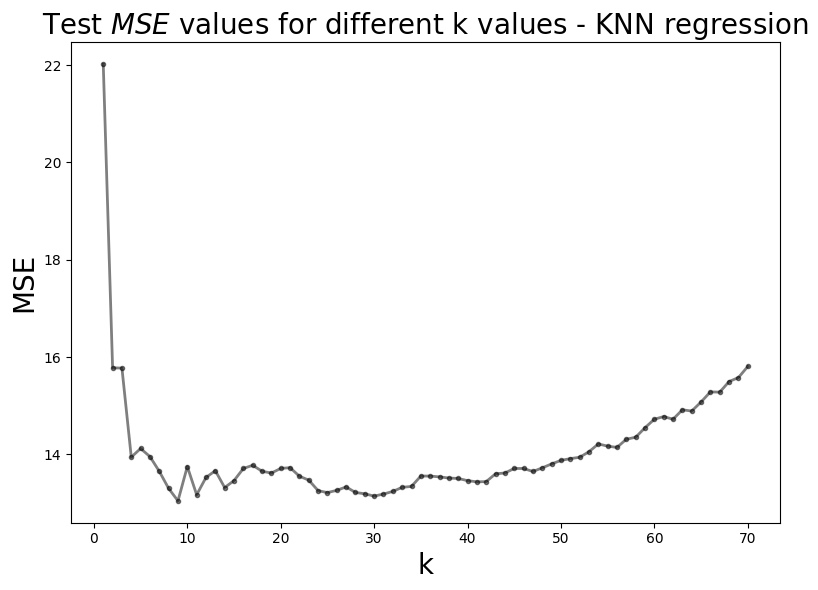

In [6]:
ax.legend(loc='lower right',fontsize=20)
ax.plot(x_train, y_train,'x',label='test',color='k')
ax.set_xlabel('TV budget in $1000',fontsize=20)
ax.set_ylabel('Sales in $1000',fontsize=20)
plt.tight_layout()

# Plot a graph which depicts the relation between the k values and MSE
plt.figure(figsize=(8,6))
plt.plot(list(knn_dict.keys()), list(knn_dict.values()),'k.-',alpha=0.5,linewidth=2)

# Set the title and axis labels
plt.xlabel('k',fontsize=20)
plt.ylabel('MSE',fontsize = 20)
plt.title('Test $MSE$ values for different k values - KNN regression',fontsize=20)
plt.tight_layout()

min_mse = min(knn_dict.values())

# Use list comprehensions to find the k value associated with the lowest MSE
best_model = [key  for (key, value) in knn_dict.items() if value == min_mse]

# Print the best k-value
print ("The best k value is ",best_model,"with a MSE of ", min_mse)